# Animated Track Animation

The goal of this notebook is to compare the two drivers on an animated track display.  
It is inspired by the Live Timing feature of the official Formula One website.

### 1. Import packages and Load Session

In [1]:
import fastf1 as ff1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from utility import set_dark

ff1.Cache.enable_cache('./data/cache')

import warnings # for clearner outputs
warnings.filterwarnings("ignore")

In [4]:
season = 2025
race = 'Monza'
session_type = 'Q' # 'FP1', 'FP2', 'FP3', 'Q', 'S', 'R'

session = ff1.get_session(season, race, session_type)
session.load()

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

### 2. Retrieve Relevant Data

The _telemetry data_ from `FastF1` provides x, y, z coordinates for the relative car position.   
This should be? useful to plot each vehicle on the track map.

In [12]:
driver1 = 'VER'
driver2 = 'NOR'

# fastest lap 
driver1_fastest = session.laps.pick_drivers(driver1).pick_fastest()
driver2_fastest = session.laps.pick_drivers(driver2).pick_fastest()

# telemetry data
tel1 = driver1_fastest.get_telemetry()
tel2 = driver2_fastest.get_telemetry()

tel1

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2025-09-06 15:00:53.955,0 days 01:13:33.378000,,802.070000,0 days 00:00:00,11381.404580,321.645455,8,100.0,False,8,interpolation,0.018979,0.000003,OnTrack,-1373.650597,-676.336105,1871.232164
3,2025-09-06 15:00:54.242,0 days 01:13:33.665000,,802.070000,0 days 00:00:00.287000,11459.024983,322.950000,8,100.0,False,8,pos,25.822479,0.004472,OnTrack,-1346.000000,-352.000000,1873.000000
4,2025-09-06 15:00:54.253,0 days 01:13:33.676000,,802.070000,0 days 00:00:00.298000,11462.000000,323.000000,8,100.0,False,14,car,26.816111,0.004644,OnTrack,-1345.304479,-344.042629,1873.058849
5,2025-09-06 15:00:54.414,0 days 01:13:33.837000,4,802.070000,0 days 00:00:00.459000,11415.000000,326.000000,8,100.0,False,12,car,41.395556,0.007169,OnTrack,-1337.809285,-260.635587,1873.822443
6,2025-09-06 15:00:54.502,0 days 01:13:33.925000,4,797.767775,0 days 00:00:00.547000,11446.376061,326.490251,8,100.0,False,12,pos,49.387330,0.008553,OnTrack,-1333.000000,-207.000000,1874.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,2025-09-06 15:02:12.422,0 days 01:14:51.845000,4,630.807216,0 days 00:01:18.467000,11190.337507,314.778126,8,100.0,False,8,pos,5725.894955,0.991603,OnTrack,-1398.000000,-979.000000,1870.000000
585,2025-09-06 15:02:12.493,0 days 01:14:51.916000,4,628.499722,0 days 00:01:18.538000,11193.000000,315.000000,8,100.0,False,8,car,5732.114722,0.992680,OnTrack,-1393.104911,-914.946997,1870.436860
586,2025-09-06 15:02:12.582,0 days 01:14:52.005000,4,625.508327,0 days 00:01:18.627000,11214.508380,315.370834,8,100.0,False,8,pos,5739.916998,0.994032,OnTrack,-1387.000000,-836.000000,1871.000000
587,2025-09-06 15:02:12.733,0 days 01:14:52.156000,4,620.433056,0 days 00:01:18.778000,11251.000000,316.000000,8,100.0,False,10,car,5753.181389,0.996329,OnTrack,-1376.364779,-703.244855,1871.685519


In [24]:
# z coord is not need because the track map is 2D.
driver1_x = tel1['X'].values
driver1_y = tel1['Y'].values
driver2_x = tel2['X'].values
driver2_y = tel2['Y'].values

driver1_time = tel1['Time'].dt.total_seconds().values # .values makes it a numpy array. otherwise, just a laptime in seconds
driver2_time = tel2['Time'].dt.total_seconds().values

# driver1_time

### 3. Track & Driver Plots

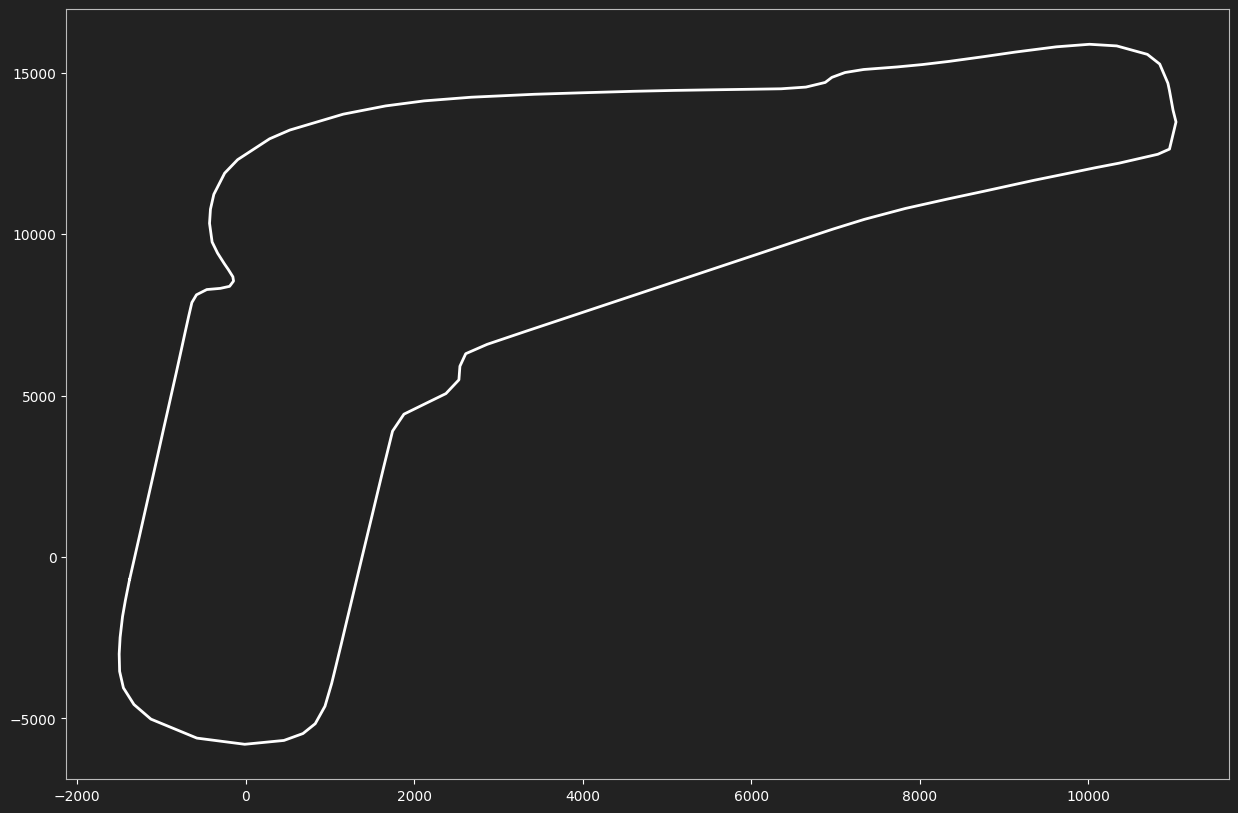

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
set_dark(ax)

step = 5
ax.plot(driver1_x[::step], driver1_y[::step], color='white', label='Track Layout', linewidth=2)

driver1_point = ax.plot([], [], 'o', color=)